# Vanishing / Exploding Gradient Experiments

This notebook runs and compares multiple deep neural-network configurations on MNIST.

The neural network itself is implemented from scratch with **NumPy**.  
The notebook is responsible only for:

- loading prepared data;
- running experiment configurations from `config.py`;
- saving experiment histories;
- evaluating trained models;
- visualizing gradient behavior, loss, and accuracy.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import config

from src.NeuralNetwork import NeuralNetwork
from src.visualize import (
    plot_experiment_summary,
    plot_grad_by_layer,
    plot_grad_over_epochs,
    save_figure,
    save_history,
)

np.set_printoptions(precision=6, suppress=True)

## 1. Prepare result directories


In [2]:
config.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
config.HISTORY_DIR.mkdir(parents=True, exist_ok=True)
config.FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Results directory :", config.RESULTS_DIR)
print("History directory :", config.HISTORY_DIR)
print("Figure directory  :", config.FIGURE_DIR)

Results directory : D:\HCMUT\AIO\Conquer4\Gradient-Vanishing-and-Solution\results
History directory : D:\HCMUT\AIO\Conquer4\Gradient-Vanishing-and-Solution\results\histories
Figure directory  : D:\HCMUT\AIO\Conquer4\Gradient-Vanishing-and-Solution\results\figures


## 2. Load MNIST data


In [3]:
X_train = np.load(config.DATA_DIR / "X_train.npy")
y_train = np.load(config.DATA_DIR / "y_train.npy")

X_val = np.load(config.DATA_DIR / "X_val.npy")
y_val = np.load(config.DATA_DIR / "y_val.npy")


# NeuralNetwork expects feature-major input:
# (n_features, n_samples)
X_train = X_train.T
X_val = X_val.T

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)


Train: (784, 59500) (59500,)
Val  : (784, 10500) (10500,)


## 3. Sanity checks


In [4]:
assert X_train.shape[0] == config.INPUT_DIM
assert X_val.shape[0] == config.INPUT_DIM

assert X_train.shape[1] == y_train.shape[0]
assert X_val.shape[1] == y_val.shape[0]

assert np.isfinite(X_train).all()
assert np.isfinite(X_val).all()

print("Data checks passed.")

Data checks passed.


## 4. Experiment runner

All experiment definitions come from `config.EXPERIMENTS`.

This keeps the notebook focused on experimentation instead of repeatedly hard-coding model settings.


In [5]:
def run_experiment(experiment_key):
    if experiment_key not in config.EXPERIMENTS:
        raise KeyError(f"Unknown experiment: {experiment_key}")

    experiment = config.EXPERIMENTS[experiment_key]

    print("=" * 70)
    print(experiment["name"])
    print("=" * 70)

    model = NeuralNetwork(
        layer_dims=config.LAYER_SIZES,
        activations=experiment["activations"],
        Weights_initializer=experiment["initializer"],
        seed=config.SEED,
        use_batchnorm=experiment["use_batchnorm"],
    )

    history = model.fit(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=config.LEARNING_RATE,
        epochs=config.NUM_EPOCHS,
        batch_size=config.BATCH_SIZE,
        print_every=config.PRINT_EVERY,
    )

    history_path = config.HISTORY_DIR / f"{experiment_key}.npz"
    save_history(history, history_path)

    print(f"Saved history: {history_path}")
    print()

    return model, history

## 5. Run all configured experiments


In [6]:
models = {}
histories_by_key = {}

for experiment_key in config.EXPERIMENT_ORDER:
    model, history = run_experiment(experiment_key)

    models[experiment_key] = model
    histories_by_key[experiment_key] = history

Baseline: Sigmoid + Random Normal
Epoch: 0
Train Loss: 2.301954
Train Accuracy: 0.1125
Val Loss: 2.301951
Val Accuracy: 0.1126
----------------------------------------
Epoch: 10
Train Loss: 2.302585
Train Accuracy: 0.1125
Val Loss: 2.302581
Val Accuracy: 0.1126
----------------------------------------
Epoch: 20
Train Loss: 2.301624
Train Accuracy: 0.1125
Val Loss: 2.301615
Val Accuracy: 0.1126
----------------------------------------
Epoch: 30
Train Loss: 2.301453
Train Accuracy: 0.1125
Val Loss: 2.301443
Val Accuracy: 0.1126
----------------------------------------
Epoch: 40
Train Loss: 2.301405
Train Accuracy: 0.1125
Val Loss: 2.301399
Val Accuracy: 0.1126
----------------------------------------
Saved history: D:\HCMUT\AIO\Conquer4\Gradient-Vanishing-and-Solution\results\histories\baseline.npz

Sigmoid + He Initialization
Epoch: 0
Train Loss: 2.302121
Train Accuracy: 0.1125
Val Loss: 2.302118
Val Accuracy: 0.1126
----------------------------------------
Epoch: 10
Train Loss: 2.30302

## 6. Build named histories for plotting


In [7]:
histories = {
    config.EXPERIMENTS[key]["name"]: histories_by_key[key]
    for key in config.EXPERIMENT_ORDER
}

print("Experiments:")
for name in histories:
    print("-", name)

Experiments:
- Baseline: Sigmoid + Random Normal
- Sigmoid + He Initialization
- LeakyReLU + Random Normal
- LeakyReLU + He Initialization
- Baseline + BatchNorm


## 7. Final validation


In [8]:
print(f"{'Experiment':45s} " f"{'Val Acc':>10s} ")
print("-" * 69)

test_results = {}

for key in config.EXPERIMENT_ORDER:
    name = config.EXPERIMENTS[key]["name"]
    history = histories_by_key[key]
    model = models[key]

    final_val_acc = (
        float(history["val_acc"][-1]) if "val_acc" in history else float("nan")
    )

    print(f"{name:45s} " f"{final_val_acc:10.4f} ")

Experiment                                       Val Acc 
---------------------------------------------------------------------
Baseline: Sigmoid + Random Normal                 0.1126 
Sigmoid + He Initialization                       0.1126 
LeakyReLU + Random Normal                         0.1126 
LeakyReLU + He Initialization                     0.9721 
Baseline + BatchNorm                              0.9742 


## 8. Experiment summary

The four plots show:

1. gradient magnitude across layers;
2. first-layer / last-layer gradient ratio across epochs;
3. validation loss;
4. validation accuracy.

A very small early-to-late gradient ratio can be evidence of vanishing gradients.


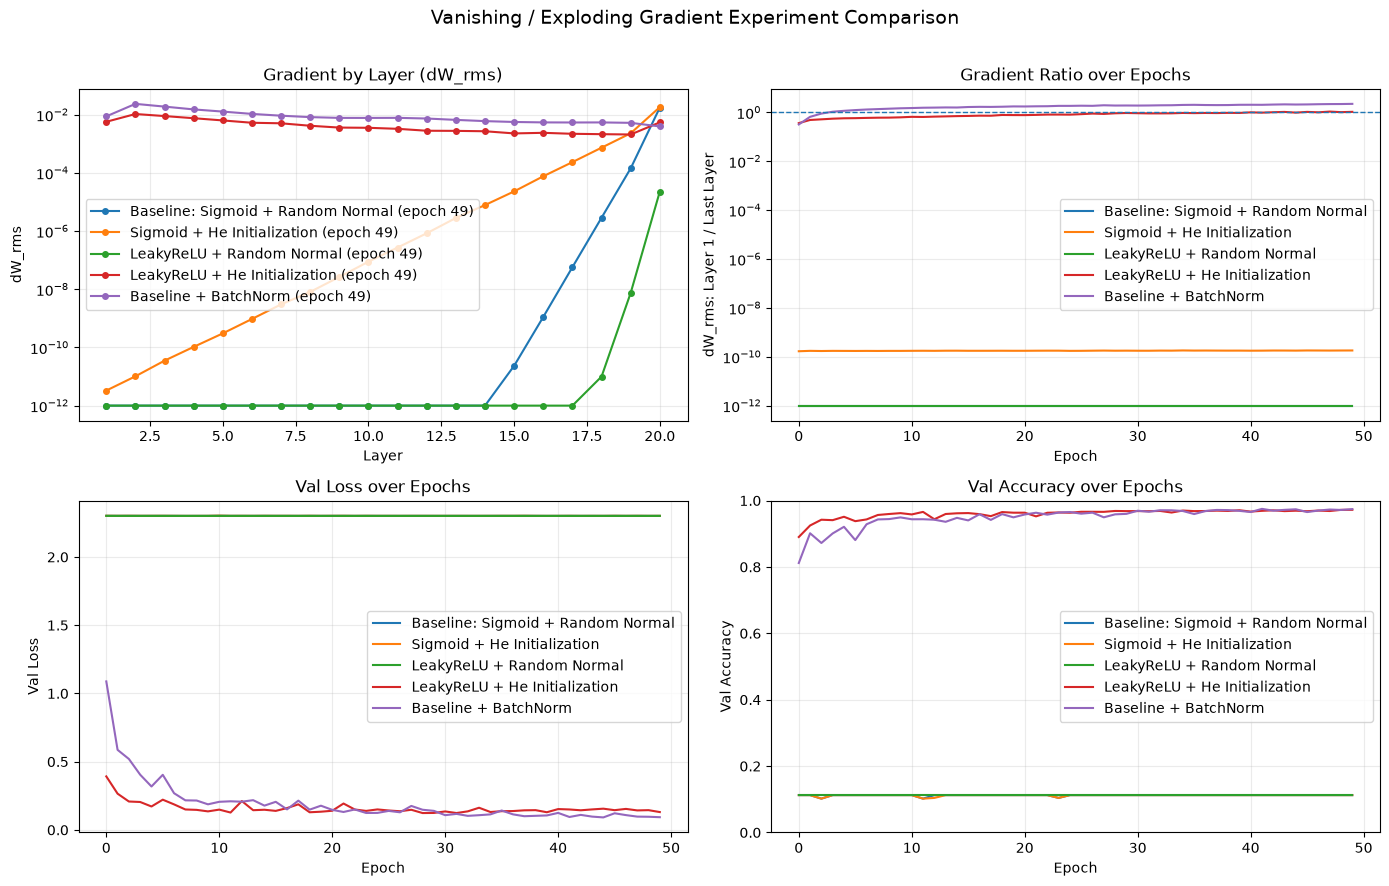

Saved figure: D:\HCMUT\AIO\Conquer4\Gradient-Vanishing-and-Solution\results\figures\experiment_summary_dW_rms.png


In [9]:
fig, axes = plot_experiment_summary(
    histories,
    epoch=-1,
    key="dW_rms",
    split="val",
)

summary_path = config.FIGURE_DIR / "experiment_summary_dW_rms.png"
save_figure(fig, summary_path)

plt.show()

print("Saved figure:", summary_path)

## 9. Compare weight-gradient magnitude by layer


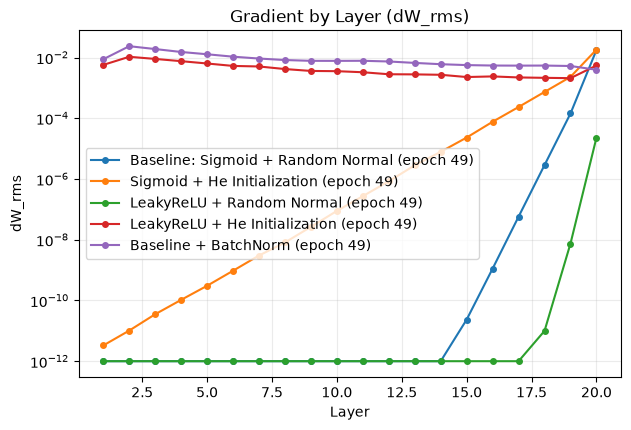

Saved figure: D:\HCMUT\AIO\Conquer4\Gradient-Vanishing-and-Solution\results\figures\gradient_by_layer_dW_rms.png


In [10]:
fig, ax = plot_grad_by_layer(
    histories,
    epoch=-1,
    key="dW_rms",
)

path = config.FIGURE_DIR / "gradient_by_layer_dW_rms.png"
save_figure(fig, path)

plt.show()

print("Saved figure:", path)

## 10. Compare gradient propagation over training


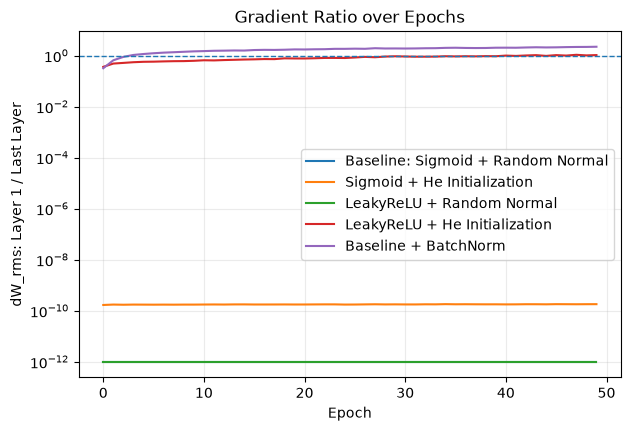

Saved figure: D:\HCMUT\AIO\Conquer4\Gradient-Vanishing-and-Solution\results\figures\gradient_ratio_dW_rms.png


In [11]:
fig, ax = plot_grad_over_epochs(
    histories,
    key="dW_rms",
    metric="ratio",
)

path = config.FIGURE_DIR / "gradient_ratio_dW_rms.png"
save_figure(fig, path)

plt.show()

print("Saved figure:", path)

## 11. Optional: inspect activation-gradient propagation


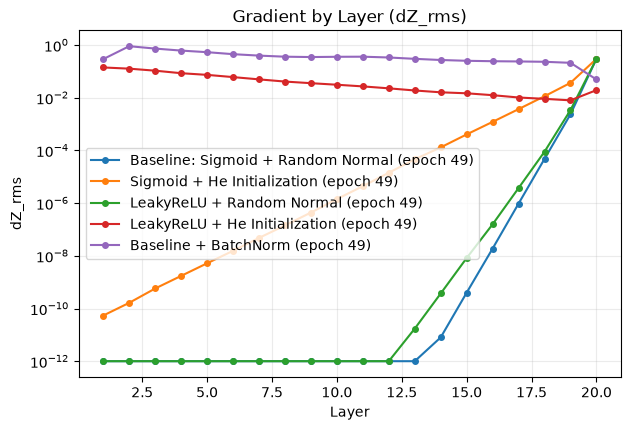

Saved figure: D:\HCMUT\AIO\Conquer4\Gradient-Vanishing-and-Solution\results\figures\gradient_by_layer_dZ_rms.png


In [12]:
fig, ax = plot_grad_by_layer(
    histories,
    epoch=-1,
    key="dZ_rms",
)

path = config.FIGURE_DIR / "gradient_by_layer_dZ_rms.png"
save_figure(fig, path)

plt.show()

print("Saved figure:", path)

## 12. Train all the model


sigmoid | noBN | random_normal
Epoch: 0
Train Loss: 2.301954
Train Accuracy: 0.1125
Val Loss: 2.301951
Val Accuracy: 0.1126
----------------------------------------
Epoch: 10
Train Loss: 2.302585
Train Accuracy: 0.1125
Val Loss: 2.302581
Val Accuracy: 0.1126
----------------------------------------
Epoch: 20
Train Loss: 2.301624
Train Accuracy: 0.1125
Val Loss: 2.301615
Val Accuracy: 0.1126
----------------------------------------
Epoch: 30
Train Loss: 2.301453
Train Accuracy: 0.1125
Val Loss: 2.301443
Val Accuracy: 0.1126
----------------------------------------
Epoch: 40
Train Loss: 2.301405
Train Accuracy: 0.1125
Val Loss: 2.301399
Val Accuracy: 0.1126
----------------------------------------
Saved history: D:\HCMUT\AIO\Conquer4\Gradient-Vanishing-and-Solution\results\histories\sweep_sigmoid_noBN_random_normal.npz

sigmoid | noBN | xavier_normal
Epoch: 0
Train Loss: 2.302072
Train Accuracy: 0.1125
Val Loss: 2.302069
Val Accuracy: 0.1126
----------------------------------------
Epoch

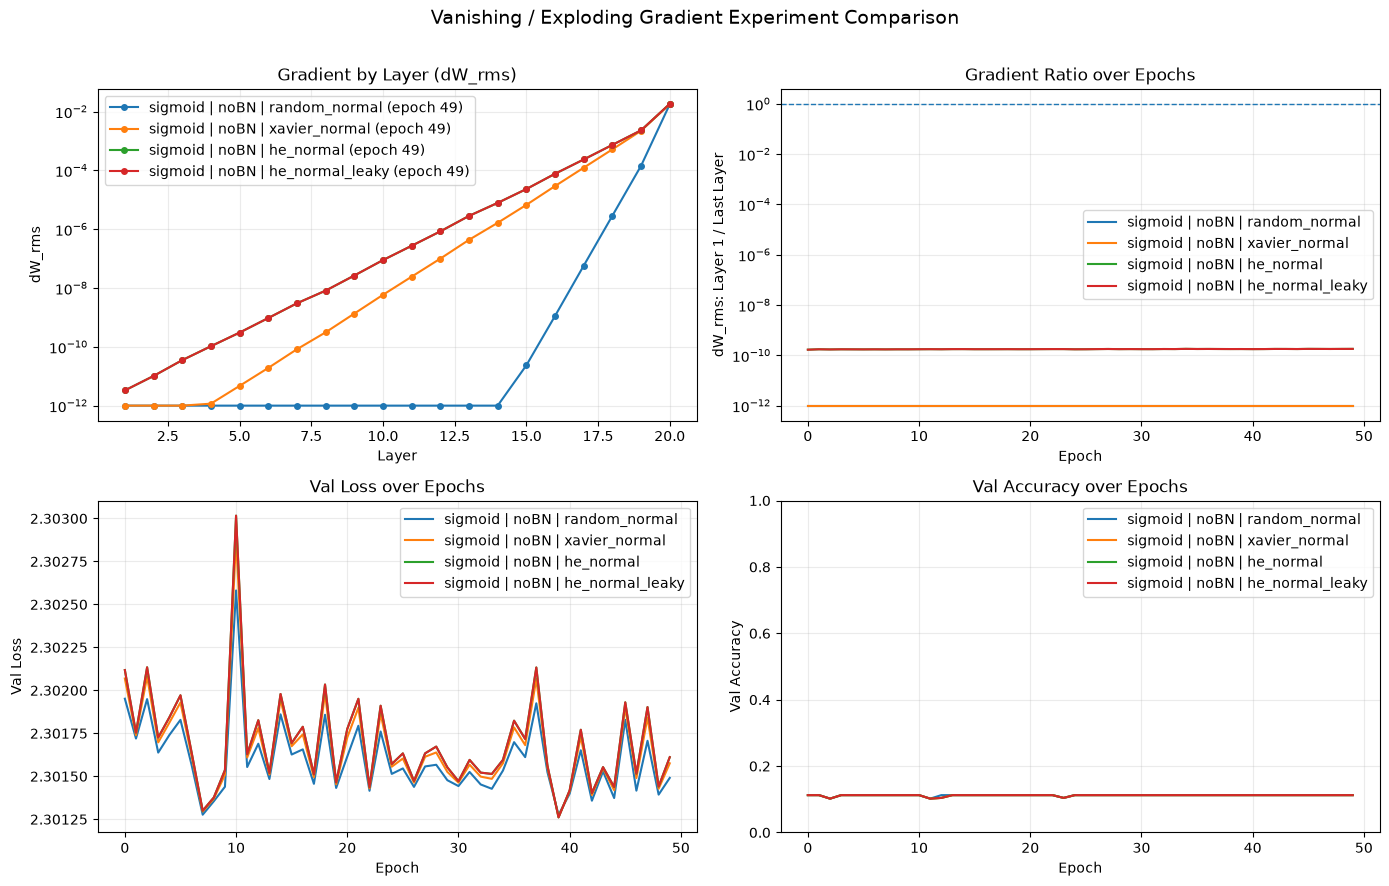

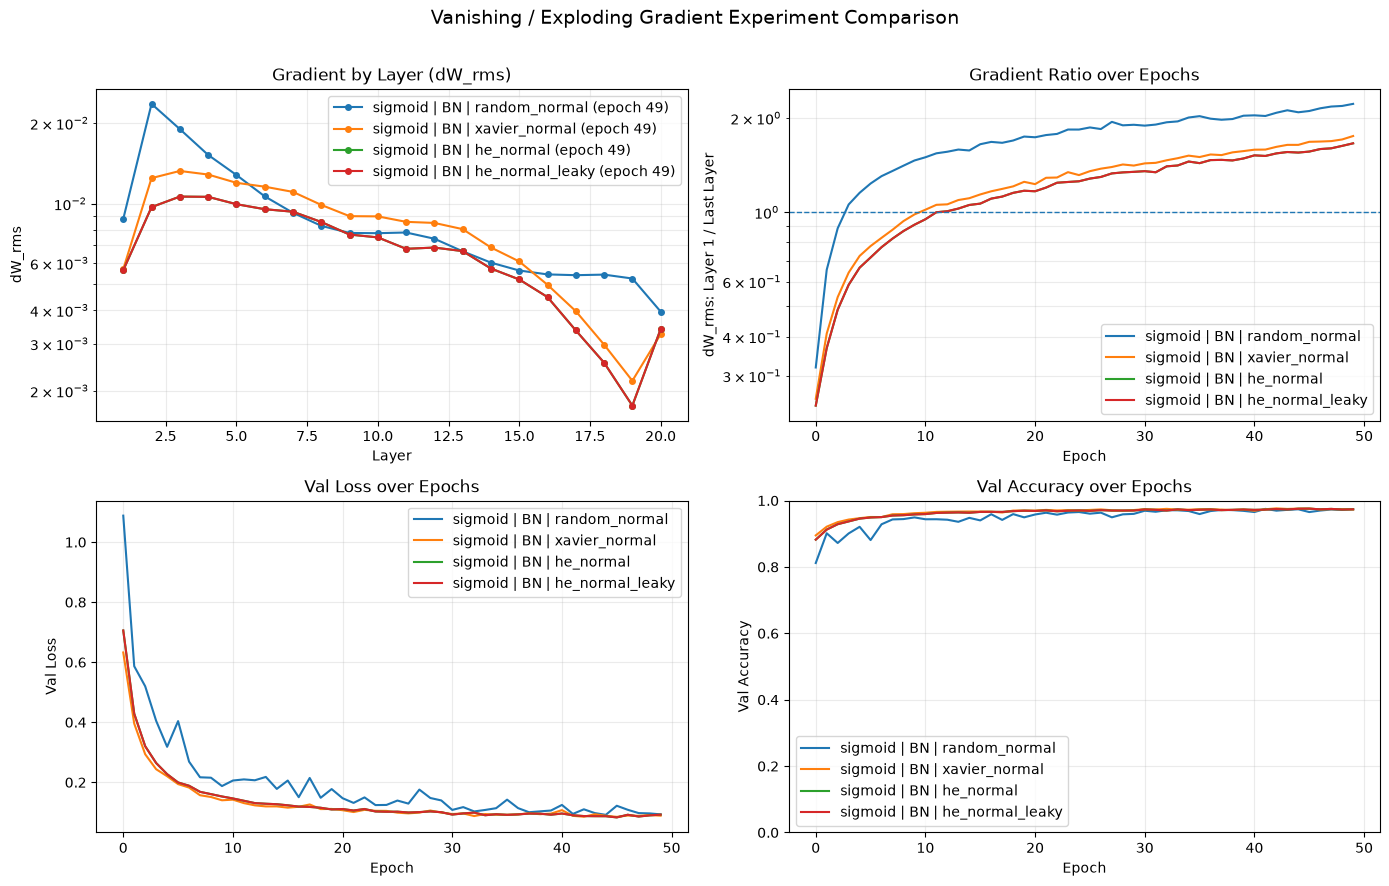

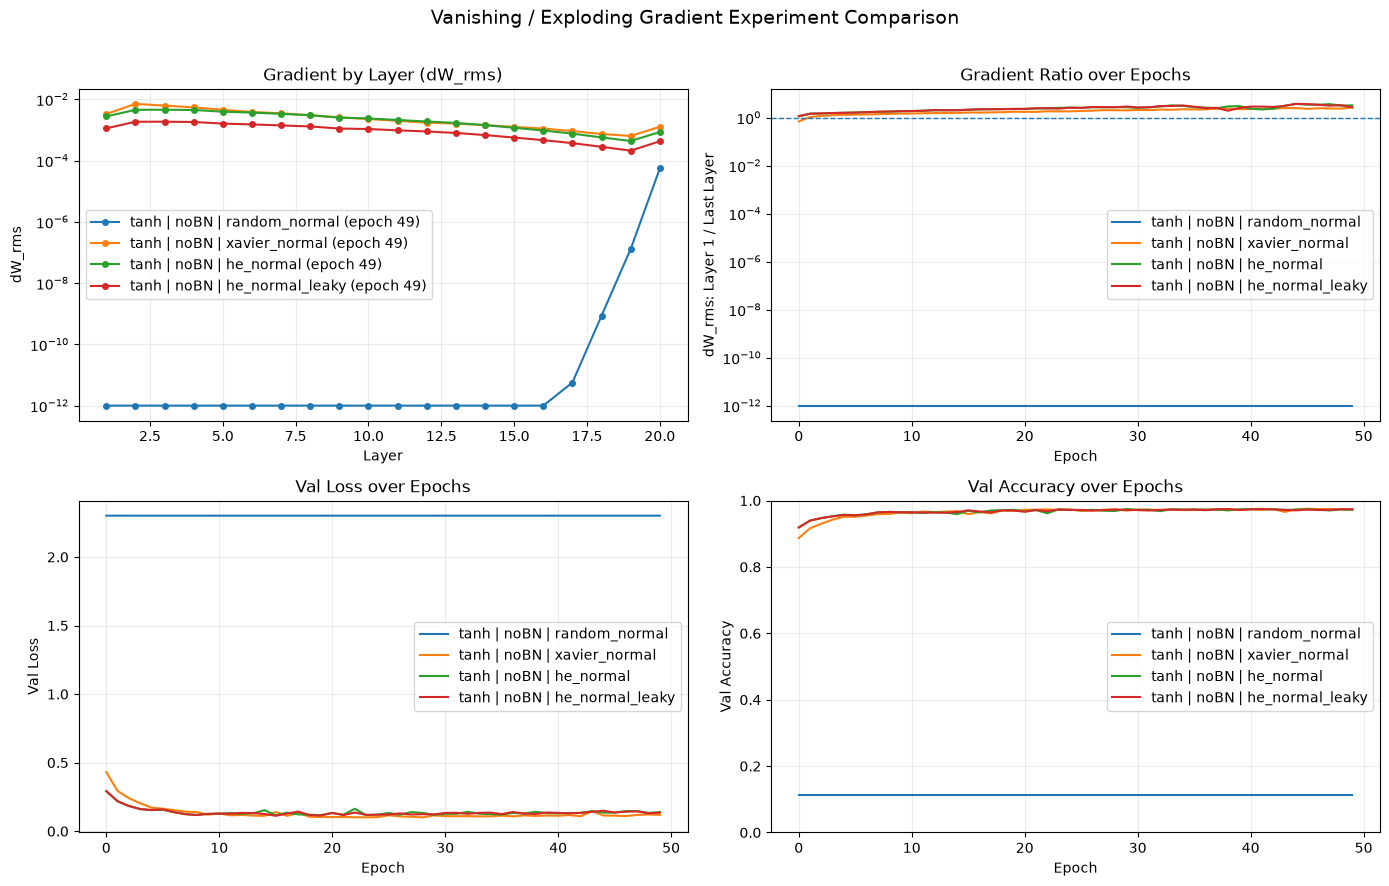

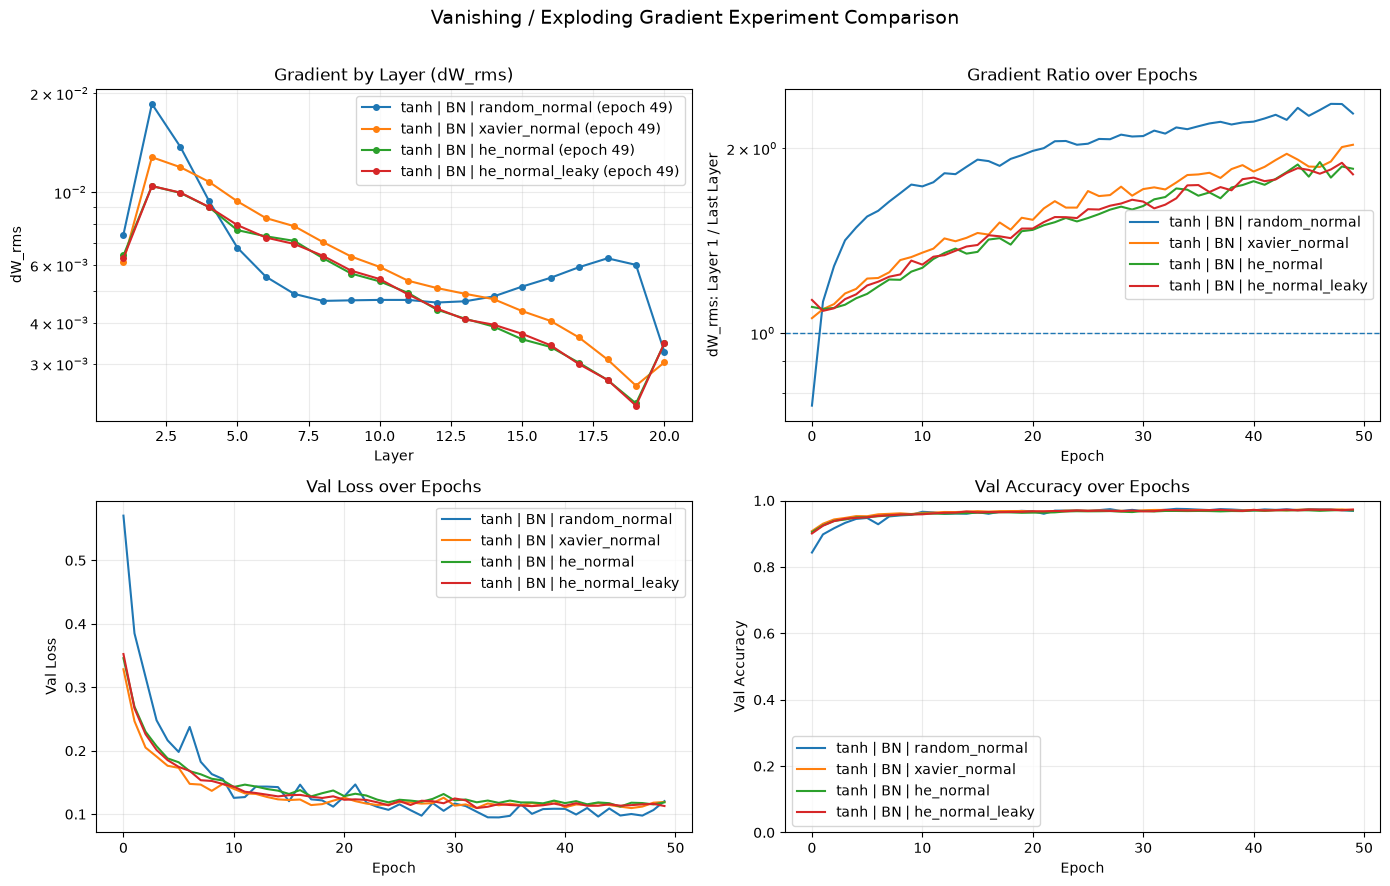

In [14]:
from config import SIGMOID_ACTIVATIONS, TANH_ACTIVATIONS
import config

INITIALIZERS = ["random_normal", "xavier_normal", "he_normal", "he_normal_leaky"]
ACTIVATIONS = {
    "sigmoid": SIGMOID_ACTIVATIONS,
    "tanh": TANH_ACTIVATIONS,
}
BN_SETTINGS = {"noBN": False, "BN": True}

# 1) Đăng ký experiment mới (prefix "sweep_" để không đụng 5 pipeline của report)
SWEEP_ORDER = []

for act_name, act_cfg in ACTIVATIONS.items():
    for bn_name, use_bn in BN_SETTINGS.items():
        for init in INITIALIZERS:
            key = f"sweep_{act_name}_{bn_name}_{init}"
            config.EXPERIMENTS[key] = {
                "name": f"{act_name} | {bn_name} | {init}",
                "activations": act_cfg,
                "initializer": init,
                "use_batchnorm": use_bn,
            }
            SWEEP_ORDER.append(key)

# 2) Train tất cả
sweep_models = {}
sweep_histories_by_key = {}

for experiment_key in SWEEP_ORDER:
    model, history = run_experiment(experiment_key)
    sweep_models[experiment_key] = model
    sweep_histories_by_key[experiment_key] = history

# 3) Gom history theo nhóm: {tên experiment: history}
def collect(act_name, bn_name):
    return {
        config.EXPERIMENTS[k]["name"]: sweep_histories_by_key[k]
        for k in SWEEP_ORDER
        if k.startswith(f"sweep_{act_name}_{bn_name}_")
    }

sigmoid_noBN = collect("sigmoid", "noBN")
sigmoid_BN   = collect("sigmoid", "BN")
tanh_noBN    = collect("tanh", "noBN")
tanh_BN      = collect("tanh", "BN")

groups = {
    "sigmoid_noBN": sigmoid_noBN,
    "sigmoid_BN": sigmoid_BN,
    "tanh_noBN": tanh_noBN,
    "tanh_BN": tanh_BN,
}

print("Experiments:")
for group_name, hist in groups.items():
    print(f"[{group_name}]")
    for name in hist:
        print("  -", name)

# 4) Hiển thị  cho từng nhóm
for group_name, hist in groups.items():
    fig, axes = plot_experiment_summary(
        hist,
        epoch=-1,
        key="dW_rms",
        split="val",
    )
    summary_path = config.FIGURE_DIR / f"sweep_{group_name}_dW_rms.png"
    save_figure(fig, summary_path)
    plt.show()